# K-Nearest Neighbors (K-NN) Algorithm – Introduction


##  How K-NN Works 

1. Choose the number of neighbors **K** (e.g., 3 or 5).
2. Calculate the **distance** between the new data point and all training points.
3. Select the **K nearest neighbors** (the closest points).
4. Take a **majority vote** of their labels.
5. Assign that label to the new point.

K-NN uses a **distance metric**, usually **Euclidean distance**



##  When to Use K-NN?

✅ Easy to understand and implement  
✅ Works well with small to medium datasets  
✅ Good baseline model for classification  
❗Sensitive to outliers  
❗Slow with very large datasets  
❗Needs feature scaling (normalization)


### 1. Importing required libraries

We import:
- `numpy` to handle numerical data and arrays
- `KNeighborsClassifier` to build the K-NN model


In [2]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

### 2. Initializing the Dataset
We create a small cybersecurity dataset related to SSH brute-force login attempts.


In [3]:
# Features: [number_of_attempts, time_interval_seconds, unique_source_ips]
X = [
    [5, 60, 1],    # Normal login activity
    [3, 45, 1],    # Normal login
    [50, 30, 10],  # Brute force pattern
    [70, 20, 15],  # Brute force pattern
    [2, 120, 1],   # Normal login
    [90, 10, 20],  # Brute force pattern
]

# Labels: 0 = Normal, 1 = Brute-force attack
y = [0, 0, 1, 1, 0, 1]


In [4]:
# 2) Convert to numpy arrays (important for the plot)
X = np.array(X)
y = np.array(y)


### 3. Training the KNN Model
We train the KNN classifier to detect brute-force attacks.


In [5]:

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)
print("K-NN trained. Neighbors:", knn.n_neighbors)


K-NN trained. Neighbors: 3


### 4. Making a Prediction
We test the model with a new connection attempt.


In [6]:
test_sample = [40, 25, 8] # 40 attempts in 25 sec from 8 IPs
ts_arr = np.array(test_sample)
prediction = knn.predict([ts_arr])
print(prediction)
print("Prediction:", "Brute Force Attack" if prediction[0] == 1 else "Normal")



[1]
Prediction: Brute Force Attack


### 5. Visualizing the Dataset (optional)
We visualize two features to see how KNN separates classes.


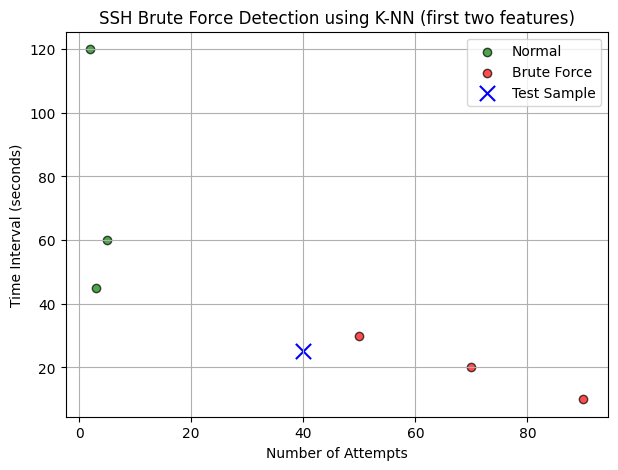

In [36]:
mask_normal = (y == 0)
mask_attack = (y == 1)

plt.figure(figsize=(7,5))
# plot each class once with labels (so legend is correct)
plt.scatter(X[mask_normal, 0], X[mask_normal, 1], c='green', label='Normal', alpha=0.7, edgecolors='k')
plt.scatter(X[mask_attack, 0], X[mask_attack, 1], c='red', label='Brute Force', alpha=0.7, edgecolors='k')

# plot test sample (first two features)
plt.scatter(ts_arr[0], ts_arr[1], c='blue', marker='x', s=120, label='Test Sample')

plt.xlabel("Number of Attempts")
plt.ylabel("Time Interval (seconds)")
plt.title("SSH Brute Force Detection using K-NN (first two features)")
plt.legend()
plt.grid(True)
plt.show()


### 6. Model Accuracy
We evaluate the model accuracy on the training dataset.



In [27]:
accuracy = knn.score(X, y)
print("Model Accuracy:", accuracy)


Model Accuracy: 1.0
